# Paired t-test untuk Signifikansi Perubahan MAE

Notebook ini dibuat untuk menguji apakah perubahan MAE antara pipeline severity estimation signifikan secara statistik menggunakan **paired t-test**.

Notebook ini **tidak membuat data sintetis atau data palsu**. Semua nilai dihitung ulang dari file prediksi asli pada folder `severity_estimation_experiment/results/.../csv/severity_prediction_test.csv` saat notebook dijalankan.

Default pengujian mengikuti klaim manuscript/reviewer response sebelumnya:

- baseline: `single_stage/single_module`
- comparison: `multi_stage/single_module_dynamic`
- metrik berpasangan: absolute error per gambar
- hipotesis utama: MAE baseline lebih tinggi daripada MAE comparison, atau two-stage menurunkan error.


## 1. Import dan Konfigurasi Path

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

ROOT = Path.cwd()
SEVERITY_RESULT_DIR = ROOT / "severity_estimation_experiment" / "results"
OUT = ROOT / "reviewer_feedback_outputs"
OUT.mkdir(exist_ok=True)

MODEL_CSV_PATHS = {
    "single_stage_single_module": SEVERITY_RESULT_DIR / "single_stage" / "single_module" / "csv" / "severity_prediction_test.csv",
    "two_stage_single_module_dynamic": SEVERITY_RESULT_DIR / "multi_stage" / "single_module_dynamic" / "csv" / "severity_prediction_test.csv",
    "single_stage_dual_module": SEVERITY_RESULT_DIR / "single_stage" / "dual_module" / "csv" / "severity_prediction_test.csv",
    "two_stage_dual_module_dynamic": SEVERITY_RESULT_DIR / "multi_stage" / "dual_module_dynamic" / "csv" / "severity_prediction_test.csv",
}

BASELINE_MODEL = "single_stage_single_module"
COMPARISON_MODEL = "two_stage_single_module_dynamic"
ALPHA = 0.05

## 2. Fungsi Baca Data Prediksi Asli

File prediksi menyimpan severity dalam format persen, misalnya `1.30%`. Fungsi di bawah hanya mengubah format tersebut menjadi angka float dalam satuan percentage points.

In [2]:
def parse_percent(value):
    """Convert values such as '1.30%' to 1.30. Numeric values are returned as float."""
    if pd.isna(value):
        return np.nan
    if isinstance(value, str):
        value = value.strip().replace("%", "")
    return float(value)


def load_prediction_csv(model_name, csv_path):
    csv_path = Path(csv_path)
    if not csv_path.exists():
        raise FileNotFoundError(f"CSV tidak ditemukan untuk {model_name}: {csv_path}")

    df = pd.read_csv(csv_path)
    required_columns = {"nama_file", "gt_severity", "pred_severity"}
    missing_columns = required_columns - set(df.columns)
    if missing_columns:
        raise ValueError(f"Kolom wajib tidak ada pada {csv_path}: {sorted(missing_columns)}")

    out = df[["nama_file", "gt_severity", "pred_severity"]].copy()
    out["gt"] = out["gt_severity"].apply(parse_percent)
    out[f"pred_{model_name}"] = out["pred_severity"].apply(parse_percent)
    out[f"abs_error_{model_name}"] = (out[f"pred_{model_name}"] - out["gt"]).abs()

    out = out[["nama_file", "gt", f"pred_{model_name}", f"abs_error_{model_name}"]]
    if out.isna().any().any():
        na_counts = out.isna().sum()
        raise ValueError(f"Ada nilai kosong setelah parsing pada {csv_path}:\n{na_counts}")

    return out


predictions = {
    model_name: load_prediction_csv(model_name, csv_path)
    for model_name, csv_path in MODEL_CSV_PATHS.items()
}

pd.DataFrame(
    [
        {
            "model": model_name,
            "n_images": len(df),
            "mae_pct_point": df[f"abs_error_{model_name}"].mean(),
        }
        for model_name, df in predictions.items()
    ]
)

,model,n_images,mae_pct_point
0,single_stage_single_module,149,1.488188
1,two_stage_single_module_dynamic,149,0.660268
2,single_stage_dual_module,149,0.389664
3,two_stage_dual_module_dynamic,149,0.482282


## 3. Bentuk Pasangan Error per Gambar

Paired t-test harus memakai gambar yang sama pada dua model/pipeline. Karena itu, data digabung berdasarkan `nama_file` dan hanya pasangan yang tersedia di kedua file yang digunakan.

`mae_reduction_pct_point` didefinisikan sebagai:

`absolute_error_baseline - absolute_error_comparison`

Nilai positif berarti pipeline comparison memiliki error lebih kecil daripada baseline.

In [3]:
def build_paired_error_table(baseline_model, comparison_model):
    baseline = predictions[baseline_model]
    comparison = predictions[comparison_model]

    paired = baseline.merge(comparison, on=["nama_file", "gt"], how="inner")
    if paired.empty:
        raise ValueError("Tidak ada pasangan gambar yang sama antara dua CSV.")

    baseline_error_col = f"abs_error_{baseline_model}"
    comparison_error_col = f"abs_error_{comparison_model}"
    paired["mae_reduction_pct_point"] = paired[baseline_error_col] - paired[comparison_error_col]

    return paired


paired = build_paired_error_table(BASELINE_MODEL, COMPARISON_MODEL)
paired_output_path = OUT / "severity_paired_errors_for_ttest_single_vs_two_stage.csv"
paired.to_csv(paired_output_path, index=False)

paired.head()

,nama_file,gt,pred_single_stage_single_module,abs_error_single_stage_single_module,pred_two_stage_single_module_dynamic,abs_error_two_stage_single_module_dynamic,mae_reduction_pct_point
0,03482_frog_eye_leaf_spot_jpg.rf.90398efdee4de1...,1.30,0.92,0.38,2.10,0.80,-0.42
1,03483_frog_eye_leaf_spot_jpg.rf.5a8b977e35200c...,0.59,0.09,0.50,0.64,0.05,0.45
2,03484_frog_eye_leaf_spot_jpg.rf.c0be1d3f7e2f7c...,0.85,0.09,0.76,0.92,0.07,0.69
3,03485_frog_eye_leaf_spot_jpg.rf.8bd62f613fe0c0...,3.23,1.91,1.32,2.85,0.38,0.94
4,03486_frog_eye_leaf_spot_jpg.rf.d5b7c711a2225e...,0.93,0.17,0.76,0.76,0.17,0.59


## 4. Paired t-test

Hipotesis utama untuk klaim improvement:

- H0: mean absolute error baseline <= mean absolute error comparison
- H1: mean absolute error baseline > mean absolute error comparison

Dengan definisi `mae_reduction_pct_point = baseline_error - comparison_error`, H1 sama dengan mean reduction > 0.

Notebook ini juga menghitung p-value two-sided sebagai pelengkap.

In [4]:
def paired_ttest_summary(paired_df, baseline_model, comparison_model, alpha=0.05):
    baseline_error_col = f"abs_error_{baseline_model}"
    comparison_error_col = f"abs_error_{comparison_model}"

    baseline_errors = paired_df[baseline_error_col].to_numpy(dtype=float)
    comparison_errors = paired_df[comparison_error_col].to_numpy(dtype=float)
    reductions = baseline_errors - comparison_errors

    n = len(reductions)
    if n < 2:
        raise ValueError("Paired t-test membutuhkan minimal dua pasangan observasi.")

    mean_reduction = reductions.mean()
    sd_reduction = reductions.std(ddof=1)
    se_reduction = sd_reduction / np.sqrt(n)
    dfree = n - 1

    if sd_reduction == 0:
        raise ValueError("Semua paired differences identik; t-test tidak dapat dihitung.")

    t_statistic = mean_reduction / se_reduction
    pvalue_one_sided = stats.t.sf(t_statistic, df=dfree)
    pvalue_two_sided = 2 * stats.t.sf(abs(t_statistic), df=dfree)

    t_crit = stats.t.ppf(1 - alpha / 2, df=dfree)
    ci_low = mean_reduction - t_crit * se_reduction
    ci_high = mean_reduction + t_crit * se_reduction

    cohen_dz = mean_reduction / sd_reduction

    shapiro_statistic = np.nan
    shapiro_pvalue = np.nan
    if 3 <= n <= 5000:
        shapiro_statistic, shapiro_pvalue = stats.shapiro(reductions)

    summary = pd.DataFrame(
        [
            {
                "comparison": f"{baseline_model} minus {comparison_model}",
                "n_paired_images": n,
                "baseline_model": baseline_model,
                "comparison_model": comparison_model,
                "baseline_mae_pct_point": baseline_errors.mean(),
                "comparison_mae_pct_point": comparison_errors.mean(),
                "mean_mae_reduction_pct_point": mean_reduction,
                "sd_paired_reduction": sd_reduction,
                "se_paired_reduction": se_reduction,
                "ci95_mean_reduction_low": ci_low,
                "ci95_mean_reduction_high": ci_high,
                "t_statistic": t_statistic,
                "degrees_of_freedom": dfree,
                "paired_ttest_pvalue_one_sided_baseline_gt_comparison": pvalue_one_sided,
                "paired_ttest_pvalue_two_sided": pvalue_two_sided,
                "cohen_dz": cohen_dz,
                "n_images_improved": int((reductions > 0).sum()),
                "n_images_worse": int((reductions < 0).sum()),
                "n_images_equal": int((reductions == 0).sum()),
                "shapiro_wilk_statistic_on_reductions": shapiro_statistic,
                "shapiro_wilk_pvalue_on_reductions": shapiro_pvalue,
                "alpha": alpha,
                "significant_one_sided": bool(pvalue_one_sided < alpha),
                "significant_two_sided": bool(pvalue_two_sided < alpha),
            }
        ]
    )
    return summary


ttest_summary = paired_ttest_summary(paired, BASELINE_MODEL, COMPARISON_MODEL, ALPHA)
summary_output_path = OUT / "severity_mae_paired_ttest_single_vs_two_stage.csv"
ttest_summary.to_csv(summary_output_path, index=False)
ttest_summary

,comparison,n_paired_images,baseline_model,comparison_model,baseline_mae_pct_point,comparison_mae_pct_point,mean_mae_reduction_pct_point,sd_paired_reduction,se_paired_reduction,ci95_mean_reduction_low,...,paired_ttest_pvalue_two_sided,cohen_dz,n_images_improved,n_images_worse,n_images_equal,shapiro_wilk_statistic_on_reductions,shapiro_wilk_pvalue_on_reductions,alpha,significant_one_sided,significant_two_sided
0,single_stage_single_module minus two_stage_sin...,149,single_stage_single_module,two_stage_single_module_dynamic,1.488188,0.660268,0.827919,1.947485,0.159544,0.512641,...,6.845053e-07,0.425122,80,18,51,0.523413,5.077176e-20,0.05,True,True


## 5. Diagnostic Plot untuk Paired Differences

Paired t-test mengasumsikan bahwa distribusi paired differences cukup mendekati normal. Plot berikut membantu memeriksa bentuk distribusi `mae_reduction_pct_point`. Untuk ukuran sampel yang cukup besar, t-test biasanya cukup robust, tetapi jika distribusi sangat tidak normal atau banyak nilai outlier, hasil Wilcoxon/bootstrap dari notebook sebelumnya dapat tetap dilaporkan sebagai analisis pendukung.

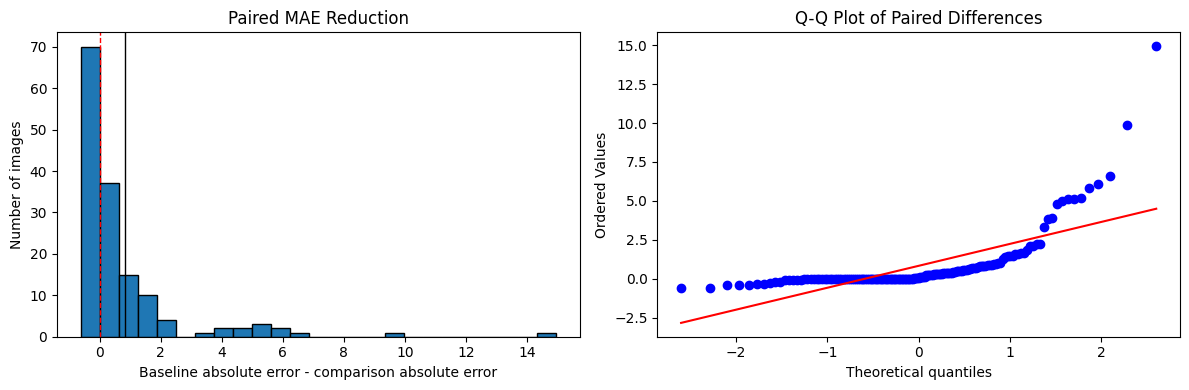

WindowsPath('c:/Users/abiyamf/Documents/Code Program/Thesis/reviewer_feedback_outputs/severity_mae_paired_ttest_diagnostics.png')

In [5]:
reductions = paired["mae_reduction_pct_point"].to_numpy(dtype=float)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(reductions, bins=25, edgecolor="black")
axes[0].axvline(0, color="red", linestyle="--", linewidth=1)
axes[0].axvline(reductions.mean(), color="black", linestyle="-", linewidth=1)
axes[0].set_title("Paired MAE Reduction")
axes[0].set_xlabel("Baseline absolute error - comparison absolute error")
axes[0].set_ylabel("Number of images")

stats.probplot(reductions, dist="norm", plot=axes[1])
axes[1].set_title("Q-Q Plot of Paired Differences")

plt.tight_layout()
plot_output_path = OUT / "severity_mae_paired_ttest_diagnostics.png"
plt.savefig(plot_output_path, dpi=300, bbox_inches="tight")
plt.show()

plot_output_path

## 6. Template Kalimat untuk Manuscript

Jalankan cell di bawah setelah hasil t-test tersedia. Teks ini hanya mengambil angka dari hasil komputasi notebook, bukan angka yang ditulis manual.

In [6]:
row = ttest_summary.iloc[0]

template_text = (
    "A paired t-test was conducted on the per-image absolute severity errors to assess "
    "whether the detection-guided two-stage pipeline significantly reduced MAE compared "
    "with the single-stage baseline. Using {n:.0f} paired test images, the baseline MAE "
    "was {baseline_mae:.3f} percentage points and the two-stage MAE was {comparison_mae:.3f} "
    "percentage points. The mean paired MAE reduction was {mean_reduction:.3f} percentage "
    "points (95% CI: {ci_low:.3f} to {ci_high:.3f}), and the one-sided paired t-test "
    "showed {significance} evidence of improvement (t({df:.0f}) = {t_stat:.3f}, "
    "p = {p_value:.3e})."
).format(
    n=row["n_paired_images"],
    baseline_mae=row["baseline_mae_pct_point"],
    comparison_mae=row["comparison_mae_pct_point"],
    mean_reduction=row["mean_mae_reduction_pct_point"],
    ci_low=row["ci95_mean_reduction_low"],
    ci_high=row["ci95_mean_reduction_high"],
    significance="statistically significant" if row["significant_one_sided"] else "no statistically significant",
    df=row["degrees_of_freedom"],
    t_stat=row["t_statistic"],
    p_value=row["paired_ttest_pvalue_one_sided_baseline_gt_comparison"],
)

print(template_text)

A paired t-test was conducted on the per-image absolute severity errors to assess whether the detection-guided two-stage pipeline significantly reduced MAE compared with the single-stage baseline. Using 149 paired test images, the baseline MAE was 1.488 percentage points and the two-stage MAE was 0.660 percentage points. The mean paired MAE reduction was 0.828 percentage points (95% CI: 0.513 to 1.143), and the one-sided paired t-test showed statistically significant evidence of improvement (t(148) = 5.189, p = 3.423e-07).


## 7. Opsional: Uji Semua Pasangan Model terhadap Baseline

Cell ini opsional. Gunakan jika ingin melihat paired t-test untuk model lain juga. Hasil default utama tetap `single_stage_single_module` vs `two_stage_single_module_dynamic`.

In [7]:
optional_summaries = []

for comparison_model in MODEL_CSV_PATHS:
    if comparison_model == BASELINE_MODEL:
        continue
    optional_paired = build_paired_error_table(BASELINE_MODEL, comparison_model)
    optional_summaries.append(
        paired_ttest_summary(optional_paired, BASELINE_MODEL, comparison_model, ALPHA)
    )

all_ttest_summary = pd.concat(optional_summaries, ignore_index=True)
all_ttest_output_path = OUT / "severity_mae_paired_ttest_all_comparisons.csv"
all_ttest_summary.to_csv(all_ttest_output_path, index=False)
all_ttest_summary

,comparison,n_paired_images,baseline_model,comparison_model,baseline_mae_pct_point,comparison_mae_pct_point,mean_mae_reduction_pct_point,sd_paired_reduction,se_paired_reduction,ci95_mean_reduction_low,...,paired_ttest_pvalue_two_sided,cohen_dz,n_images_improved,n_images_worse,n_images_equal,shapiro_wilk_statistic_on_reductions,shapiro_wilk_pvalue_on_reductions,alpha,significant_one_sided,significant_two_sided
0,single_stage_single_module minus two_stage_sin...,149,single_stage_single_module,two_stage_single_module_dynamic,1.488188,0.660268,0.827919,1.947485,0.159544,0.512641,...,6.845053e-07,0.425122,80,18,51,0.523413,5.077176e-20,0.05,True,True
1,single_stage_single_module minus single_stage_...,149,single_stage_single_module,single_stage_dual_module,1.488188,0.389664,1.098523,2.570557,0.210588,0.682375,...,6.049188e-07,0.427348,82,19,48,0.536609,9.096102e-20,0.05,True,True
2,single_stage_single_module minus two_stage_dua...,149,single_stage_single_module,two_stage_dual_module_dynamic,1.488188,0.482282,1.005906,2.445513,0.200344,0.610001,...,1.459045e-06,0.411327,81,18,50,0.539985,1.058108e-19,0.05,True,True
